In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Indic LLMLingua-2 Training

This notebook fine-tunes the LLMLingua-2 token classification model on an extended Indic dataset constructed from the original LLMLingua-2 dataset and additional XL-Sum supervision.

The objective is binary token classification, where each token is classified as either retained (1) or removed (0) during context compression.

The notebook includes:

- Dataset loading
- Model training
- Validation
- Automatic checkpointing
- Training logs
- Metric tracking
- Artifact generation

In [3]:
PROJECT_DIR = "/kaggle/working/indic_llmlingua"

DATA_DIR = "/kaggle/input/indic-llmlingua-dataset"

CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")

LOG_DIR = os.path.join(PROJECT_DIR, "logs")

PLOT_DIR = os.path.join(PROJECT_DIR, "plots")

PREDICTION_DIR = os.path.join(PROJECT_DIR, "predictions")

CONFIG_DIR = os.path.join(PROJECT_DIR, "configs")

for directory in [
    PROJECT_DIR,
    CHECKPOINT_DIR,
    LOG_DIR,
    PLOT_DIR,
    PREDICTION_DIR,
    CONFIG_DIR
]:
    os.makedirs(directory, exist_ok=True)

print("Project directory created.")

Project directory created.


# Install Dependencies

In [7]:
!nvidia-smi
!pip install evaluate   

Thu Jul 30 13:49:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(torch.cuda.get_device_name(i))

2.10.0+cu128
True
2
Tesla T4
Tesla T4


# Import Libraries

In [8]:
import os
import json
import random
import numpy as np
import pandas as pd

from datasets import Dataset

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
)

import evaluate

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)

In [9]:
!git clone https://github.com/microsoft/LLMLingua.git
!ls LLMLingua

fatal: destination path 'LLMLingua' already exists and is not an empty directory.
CODE_OF_CONDUCT.md  images     pyproject.toml  setup.py
DOCUMENT.md	    LICENSE    README.md       SUPPORT.md
examples	    llmlingua  SECURITY.md     tests
experiments	    Makefile   setup.cfg       Transparency_FAQ.md


In [11]:
!pwd
!ls

/kaggle/working
indic_llmlingua  LLMLingua


## Load Training Dataset

The dataset consists of token-level binary labels for context compression.

Each sample contains:

- question
- original_answer
- tokens
- labels

The dataset is stored in JSONL format.

In [12]:
INPUT_DIR = "/kaggle/input"

print("Available Datasets:\n")

for dataset in os.listdir(INPUT_DIR):
    print(dataset)

Available Datasets:

datasets


In [13]:
import os

DATASET_PATH = "/kaggle/input/datasets"

print("=" * 80)
print("Dataset Contents")
print("=" * 80)

for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    sub_indent = " " * 4 * (level + 1)
    for file in files:
        print(f"{sub_indent}{file}")

Dataset Contents
datasets/
    blurrydev/
        indic-lingua-data/
            val.jsonl
            test.jsonl
            train.jsonl


In [14]:
DATASET_PATH = "/kaggle/input/datasets/blurrydev/indic-lingua-data"

In [15]:
from datasets import load_dataset

DATASET_PATH = "/kaggle/input/datasets/blurrydev/indic-lingua-data"

dataset = load_dataset(
    "json",
    data_files={
        "train": f"{DATASET_PATH}/train.jsonl",
        "validation": f"{DATASET_PATH}/val.jsonl",
        "test": f"{DATASET_PATH}/test.jsonl",
    },
)

print(dataset)

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['question', 'original_answer', 'tokens', 'labels'],
        num_rows: 1609
    })
    validation: Dataset({
        features: ['question', 'original_answer', 'tokens', 'labels'],
        num_rows: 201
    })
    test: Dataset({
        features: ['question', 'original_answer', 'tokens', 'labels'],
        num_rows: 202
    })
})


In [16]:
print("Train Samples      :", len(dataset["train"]))
print("Validation Samples :", len(dataset["validation"]))
print("Test Samples       :", len(dataset["test"]))

sample = dataset["train"][0]

print("\nColumns:")
print(sample.keys())

print("\nQuestion:")
print(sample["question"])

print("\nOriginal Answer:")
print(sample["original_answer"])

print("\nFirst 20 Tokens:")
print(sample["tokens"][:20])

print("\nFirst 20 Labels:")
print(sample["labels"][:20])

print("\nTotal Tokens:", len(sample["tokens"]))
print("Total Labels:", len(sample["labels"]))

Train Samples      : 1609
Validation Samples : 201
Test Samples       : 202

Columns:
dict_keys(['question', 'original_answer', 'tokens', 'labels'])

Question:
अमरीकी वैज्ञानिकों ने एच5एन1 वायरस के बारे में क्या पुष्टि की है और इससे मनुष्यों के लिए क्या खतरा बढ़ गया है?

Original Answer:
अमरीकी वैज्ञानिकों ने पुष्टि की है कि एच5एन1 वायरस दो अलग विषाणुओं में बदल चुका है, जिससे मनुष्यों के लिए खतरा बढ़ गया है।

First 20 Tokens:
['विश्व', 'स्वास्थ्य', 'संगठन', 'ने', 'बताया', 'है', 'कि', 'बर्ड', 'फ़्लू', 'के', 'एच5एन1', 'वायरस', 'से', 'मौत', 'के', 'ताज़ा', 'मामले', 'अज़रबैजान', 'में', 'सामने']

First 20 Labels:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Total Tokens: 256
Total Labels: 256


# Experiment Configuration

This section defines the experiment configuration and fixes all random seeds to ensure reproducible training.

Using a fixed random seed ensures that data shuffling, weight initialization, and training behaviour remain consistent across runs.

In [17]:
import os
import random
import numpy as np
import torch

# ==========================================================
# Experiment Configuration
# ==========================================================

MODEL_NAME = "FacebookAI/xlm-roberta-base"

MAX_LENGTH = 512

NUM_LABELS = 2

SEED = 42

OUTPUT_DIR = "/kaggle/working/outputs"

CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")

LOG_DIR = os.path.join(OUTPUT_DIR, "logs")

PREDICTION_DIR = os.path.join(OUTPUT_DIR, "predictions")

PLOT_DIR = os.path.join(OUTPUT_DIR, "plots")

CONFIG_DIR = os.path.join(OUTPUT_DIR, "configs")

for directory in [
    OUTPUT_DIR,
    CHECKPOINT_DIR,
    LOG_DIR,
    PREDICTION_DIR,
    PLOT_DIR,
    CONFIG_DIR,
]:
    os.makedirs(directory, exist_ok=True)

print("Directories created successfully.")

Directories created successfully.


In [18]:
def set_seed(seed: int = 42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


set_seed(SEED)

print(f"Random Seed Fixed : {SEED}")

Random Seed Fixed : 42


In [19]:
import json

experiment_config = {

    "model_name": MODEL_NAME,

    "max_length": MAX_LENGTH,

    "num_labels": NUM_LABELS,

    "seed": SEED,

}

with open(os.path.join(CONFIG_DIR, "experiment_config.json"), "w") as fp:
    json.dump(experiment_config, fp, indent=4)

print("Experiment configuration saved.")

Experiment configuration saved.


# Tokenizer

The multilingual XLM-RoBERTa tokenizer is used to tokenize the input while preserving the alignment between words and token-level labels.

Since XLM-RoBERTa uses SentencePiece tokenization, a single word may be split into multiple subword tokens. During training, labels are assigned only to the first subword, while subsequent subwords are ignored using the label value `-100`.

In [20]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True
)

print("Tokenizer Loaded Successfully")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer Loaded Successfully


In [21]:
sample = dataset["train"][0]

encoding = tokenizer(
    sample["tokens"],
    is_split_into_words=True
)

print("Original Tokens :", len(sample["tokens"]))
print("Encoded Tokens  :", len(encoding["input_ids"]))

Original Tokens : 256
Encoded Tokens  : 392


# Tokenization and Label Alignment

The dataset contains labels at the word level, whereas XLM-RoBERTa operates at the subword level.

During tokenization, a single word may be split into multiple subword tokens. To maintain correct supervision:

- The original label is assigned only to the first subword.
- Remaining subwords are ignored during loss computation by assigning a label of `-100`.
- Special tokens and padding tokens are also assigned `-100`.

This follows the standard Hugging Face token classification pipeline.

In [22]:
IGNORE_LABEL = -100

def tokenize_and_align_labels(examples):
    """
    Tokenize input tokens and align word-level labels with subword tokens.
    """

    tokenized = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=MAX_LENGTH,
    )

    aligned_labels = []

    for batch_index in range(len(examples["tokens"])):

        word_ids = tokenized.word_ids(batch_index=batch_index)
        labels = examples["labels"][batch_index]

        previous_word = None
        label_ids = []

        for word_id in word_ids:

            # Special tokens (<s>, </s>, padding)
            if word_id is None:
                label_ids.append(IGNORE_LABEL)

            # First subword of a word
            elif word_id != previous_word:
                label_ids.append(labels[word_id])

            # Remaining subwords
            else:
                label_ids.append(IGNORE_LABEL)

            previous_word = word_id

        aligned_labels.append(label_ids)

    tokenized["labels"] = aligned_labels

    return tokenized

In [23]:
tokenized_dataset = dataset.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=dataset["train"].column_names,
    desc="Tokenizing Dataset"
)

Tokenizing Dataset:   0%|          | 0/1609 [00:00<?, ? examples/s]

Tokenizing Dataset:   0%|          | 0/201 [00:00<?, ? examples/s]

Tokenizing Dataset:   0%|          | 0/202 [00:00<?, ? examples/s]

In [24]:
sample = tokenized_dataset["train"][0]

print("Input IDs :", len(sample["input_ids"]))
print("Labels    :", len(sample["labels"]))
print("Attention :", len(sample["attention_mask"]))

Input IDs : 392
Labels    : 392
Attention : 392


In [25]:
tokens = tokenizer.convert_ids_to_tokens(sample["input_ids"])

for token, label in zip(tokens[:50], sample["labels"][:50]):
    print(f"{token:<20} {label}")

<s>                  -100
▁विश्व               1
▁स्वास्थ्य           1
▁संगठन               1
▁ने                  1
▁बताया               1
▁है                  1
▁कि                  1
▁बर्                 1
ड                    -100
▁फ़                  1
्ल                   -100
ू                    -100
▁के                  1
▁एच                  1
5                    -100
एन                   -100
1                    -100
▁                    1
वाय                  -100
रस                   -100
▁से                  1
▁मौत                 1
▁के                  1
▁ताज़ा               1
▁मामले               1
▁अ                   1
ज़र                  -100
बै                   -100
जान                  -100
▁में                 1
▁सामने               1
▁आए                  1
▁हैं                 1
.                    -100
▁अ                   1
ज़र                  -100
बै                   -100
जान                  -100
▁में                 1
▁फ़                  1
र        

In [26]:
tokenized_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels",
    ],
)

# Data Collator

The data collator dynamically pads input sequences within each batch during training.

Instead of padding every sample in the dataset to a fixed maximum length, dynamic padding minimizes unnecessary computation and improves GPU utilization.

Labels are padded using the ignore index (`-100`) so that padding tokens do not contribute to the loss.

In [27]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer,
    padding=True
)

print("Data Collator Initialized Successfully")

Data Collator Initialized Successfully


# Metrics

In [42]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)

IGNORE_LABEL = -100


def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    true_predictions = []
    true_labels = []

    for pred_seq, label_seq in zip(predictions, labels):
        for pred, label in zip(pred_seq, label_seq):

            # Ignore padding & continuation subwords
            if label == IGNORE_LABEL:
                continue

            true_predictions.append(pred)
            true_labels.append(label)

    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels,
        true_predictions,
        average="binary",
        zero_division=0,
    )

    accuracy = accuracy_score(
        true_labels,
        true_predictions,
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [43]:
print(compute_metrics)

<function compute_metrics at 0x784a37ce80e0>


# Model Initialization

The training objective is binary token classification.

The pretrained multilingual XLM-RoBERTa encoder is initialized with a token classification head consisting of two output classes:

- 0 → Remove Token
- 1 → Keep Token

The encoder weights are initialized from the pretrained checkpoint, while the classification head is initialized randomly and optimized during fine-tuning.

In [44]:
from transformers import AutoModelForTokenClassification

id2label = {
    0: "REMOVE",
    1: "KEEP"
}

label2id = {
    "REMOVE": 0,
    "KEEP": 1
}

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.weight           | MISSING    | 
classifier.bias             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [29]:
model.gradient_checkpointing_enable()

print("Gradient Checkpointing Enabled")

Gradient Checkpointing Enabled


In [30]:
print(model.config)

XLMRobertaConfig {
  "add_cross_attention": false,
  "architectures": [
    "XLMRobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "REMOVE",
    "1": "KEEP"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "KEEP": 1,
    "REMOVE": 0
  },
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "xlm-roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_past": true,
  "pad_token_id": 1,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 250002
}



In [31]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 277,454,594
Trainable Parameters : 277,454,594


In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print(device)

cuda


# Training Configuration

The model is fine-tuned using the Hugging Face Trainer API.

Model checkpoints are automatically saved after every epoch while retaining the best-performing model based on the validation F1-score.

Mixed precision (FP16) training is enabled to improve training speed and reduce GPU memory consumption.

In [60]:
import os
from transformers import TrainingArguments

# TensorBoard log directory
os.environ["TENSORBOARD_LOGGING_DIR"] = LOG_DIR

training_args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,

    # Training
    num_train_epochs=10,
    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,

    # Optimization
    weight_decay=0.01,
    warmup_steps=100,

    # Evaluation
    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="steps",
    logging_steps=20,

    # Save best model
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=2,

    # Mixed Precision
    fp16=True,

    report_to="tensorboard",

    seed=SEED,
)

In [61]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [62]:
from datetime import datetime
import json

experiment = {
    "date": str(datetime.now()),
    "model": MODEL_NAME,
    "epochs": 10,
    "learning_rate": 2e-5,
    "batch_size": 8,
    "gradient_accumulation": 2,
    "max_length": 512,
    "optimizer": "AdamW",
    "scheduler": "Linear",
    "weight_decay": 0.01,
    "warmup_steps": 100,
}

with open(f"{CONFIG_DIR}/experiment.json","w") as f:
    json.dump(experiment,f,indent=4)

print("Experiment configuration saved.")

Experiment configuration saved.


In [63]:
import torch

print("CUDA Available :", torch.cuda.is_available())

print("GPU Count :", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(torch.cuda.get_device_name(i))

CUDA Available : True
GPU Count : 2
Tesla T4
Tesla T4


In [64]:
from transformers import EarlyStoppingCallback

early_stopping = EarlyStoppingCallback(
    early_stopping_patience=2,
    early_stopping_threshold=0.0
)

print("Early stopping callback initialized.")

Early stopping callback initialized.


In [65]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [66]:
train_result = trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.659010,0.989085,0.743416,0.553425,0.493239,0.521602
2,1.646305,1.194493,0.716246,0.499810,0.758271,0.602492
3,1.503619,1.208191,0.717437,0.501214,0.748547,0.600406
4,1.576771,1.127832,0.738161,0.540539,0.511364,0.525547
5,1.383581,1.207718,0.732287,0.545009,0.338972,0.417979
6,1.236534,1.205924,0.727163,0.517105,0.573163,0.543693
7,1.264088,1.343932,0.718857,0.503351,0.648311,0.566708
8,1.219903,1.305656,0.721974,0.510488,0.477530,0.493459
9,1.102274,1.341433,0.721419,0.508769,0.512458,0.510607
10,1.078742,1.376983,0.718955,0.504245,0.533115,0.518278


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

In [67]:
val_metrics = trainer.evaluate()

print(val_metrics)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 1.1956814527511597, 'eval_accuracy': 0.7160667080056133, 'eval_precision': 0.499601321335004, 'eval_recall': 0.7571206628689798, 'eval_f1': 0.6019763930826242, 'eval_runtime': 4.5515, 'eval_samples_per_second': 44.161, 'eval_steps_per_second': 2.856, 'epoch': 10.0}


In [68]:
test_metrics = trainer.evaluate(tokenized_dataset["test"])

print(test_metrics)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 1.0577820539474487, 'eval_accuracy': 0.7603139563404464, 'eval_precision': 0.5124816446402349, 'eval_recall': 0.8008260670032125, 'eval_f1': 0.625, 'eval_runtime': 4.5308, 'eval_samples_per_second': 44.584, 'eval_steps_per_second': 2.869, 'epoch': 10.0}


In [69]:
import json
import os

SAVE_DIR = "/kaggle/working/final_model"

trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

with open(os.path.join(SAVE_DIR, "validation_metrics.json"), "w") as f:
    json.dump(val_metrics, f, indent=4)

with open(os.path.join(SAVE_DIR, "test_metrics.json"), "w") as f:
    json.dump(test_metrics, f, indent=4)

print("Everything saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Everything saved successfully.


In [70]:
!zip -r final_model.zip /kaggle/working/final_model

  adding: kaggle/working/final_model/ (stored 0%)
  adding: kaggle/working/final_model/training_args.bin (deflated 53%)
  adding: kaggle/working/final_model/tokenizer.json (deflated 77%)
  adding: kaggle/working/final_model/validation_metrics.json (deflated 45%)
  adding: kaggle/working/final_model/config.json (deflated 51%)
  adding: kaggle/working/final_model/test_metrics.json (deflated 45%)
  adding: kaggle/working/final_model/tokenizer_config.json (deflated 47%)
  adding: kaggle/working/final_model/model.safetensors (deflated 27%)


In [74]:
!ls -lh /kaggle/working

total 781M
drwxr-xr-x 2 root root 4.0K Jul 30 14:37 final_model
-rw-r--r-- 1 root root 781M Jul 30 15:05 final_model.zip
drwxr-xr-x 7 root root 4.0K Jul 30 13:47 indic_llmlingua
drwxr-xr-x 9 root root 4.0K Jul 30 13:47 LLMLingua
drwxr-xr-x 7 root root 4.0K Jul 30 13:55 outputs


In [75]:
from IPython.display import FileLink

FileLink("/kaggle/working/final_model.zip")

/kaggle/working/final_model.zip

In [76]:
import os
import shutil

artifact_dir = "/kaggle/working/submission_artifacts"
os.makedirs(artifact_dir, exist_ok=True)

# Copy metrics if they exist
for f in [
    "validation_metrics.json",
    "test_metrics.json",
    "training_log.csv",
]:
    src = f"/kaggle/working/final_model/{f}"
    if os.path.exists(src):
        shutil.copy(src, artifact_dir)

# Copy config files
for f in [
    "config.json",
    "tokenizer_config.json",
    "special_tokens_map.json",
]:
    src = f"/kaggle/working/final_model/{f}"
    if os.path.exists(src):
        shutil.copy(src, artifact_dir)

# Zip only artifacts
!zip -r /kaggle/working/submission_artifacts.zip /kaggle/working/submission_artifacts

  adding: kaggle/working/submission_artifacts/ (stored 0%)
  adding: kaggle/working/submission_artifacts/validation_metrics.json (deflated 45%)
  adding: kaggle/working/submission_artifacts/config.json (deflated 51%)
  adding: kaggle/working/submission_artifacts/test_metrics.json (deflated 45%)
  adding: kaggle/working/submission_artifacts/tokenizer_config.json (deflated 47%)


In [77]:
!find /kaggle/working -type f | sort

/kaggle/working/final_model/config.json
/kaggle/working/final_model/model.safetensors
/kaggle/working/final_model/test_metrics.json
/kaggle/working/final_model/tokenizer_config.json
/kaggle/working/final_model/tokenizer.json
/kaggle/working/final_model/training_args.bin
/kaggle/working/final_model/validation_metrics.json
/kaggle/working/final_model.zip
/kaggle/working/LLMLingua/CODE_OF_CONDUCT.md
/kaggle/working/LLMLingua/DOCUMENT.md
/kaggle/working/LLMLingua/examples/Code.ipynb
/kaggle/working/LLMLingua/examples/CoT.ipynb
/kaggle/working/LLMLingua/examples/LLMLingua2.ipynb
/kaggle/working/LLMLingua/examples/OnlineMeeting.ipynb
/kaggle/working/LLMLingua/examples/RAG.ipynb
/kaggle/working/LLMLingua/examples/RAGLlamaIndex.ipynb
/kaggle/working/LLMLingua/examples/Retrieval.ipynb
/kaggle/working/LLMLingua/experiments/llmlingua2/data_collection/collect_data.sh
/kaggle/working/LLMLingua/experiments/llmlingua2/data_collection/compression_instructions.json
/kaggle/working/LLMLingua/experiments

In [81]:
%reload_ext tensorboard

In [82]:
%tensorboard --logdir /kaggle/working/outputs/logs

Reusing TensorBoard on port 6006 (pid 4887), started 0:00:18 ago. (Use '!kill 4887' to kill it.)

<IPython.core.display.Javascript object>

In [83]:
len(trainer.state.log_history)

40

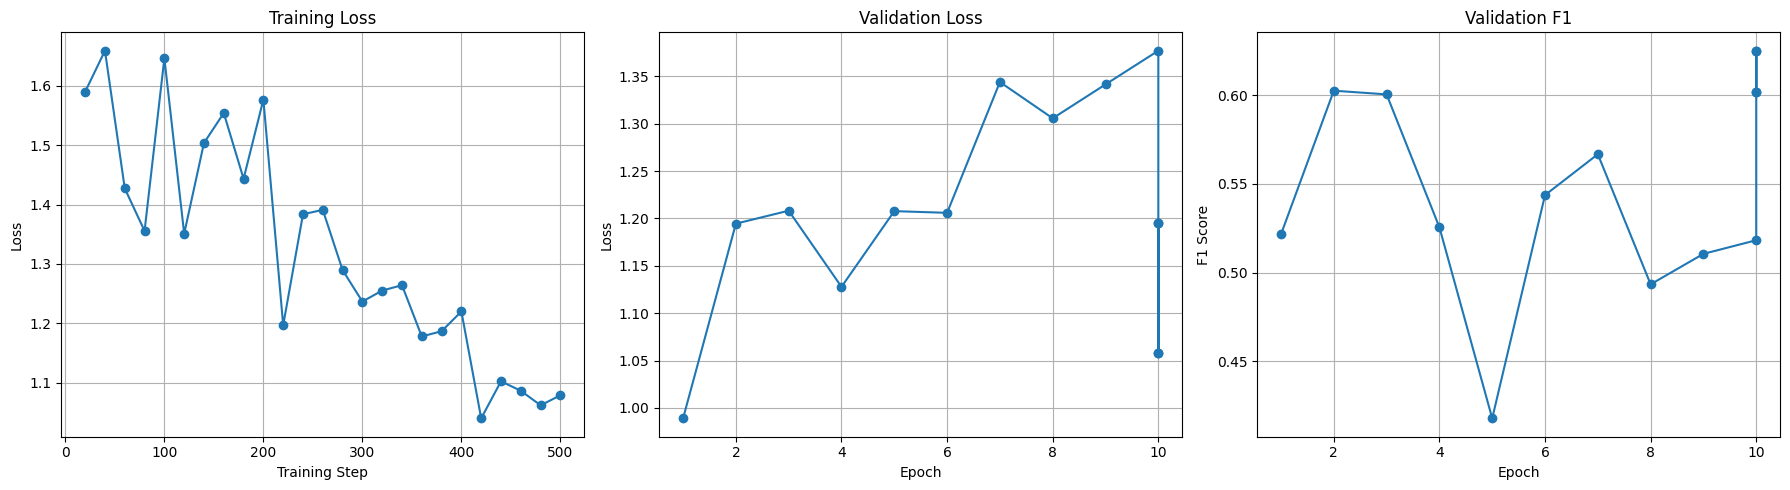

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)

train = history[history["loss"].notna()]
eval_df = history[history["eval_loss"].notna()]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# ----------------------------
# Training Loss
# ----------------------------
axes[0].plot(train["step"], train["loss"], marker="o")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Training Step")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

# ----------------------------
# Validation Loss
# ----------------------------
axes[1].plot(eval_df["epoch"], eval_df["eval_loss"], marker="o")
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True)

# ----------------------------
# Validation F1
# ----------------------------
axes[2].plot(eval_df["epoch"], eval_df["eval_f1"], marker="o")
axes[2].set_title("Validation F1")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("F1 Score")
axes[2].grid(True)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/training_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


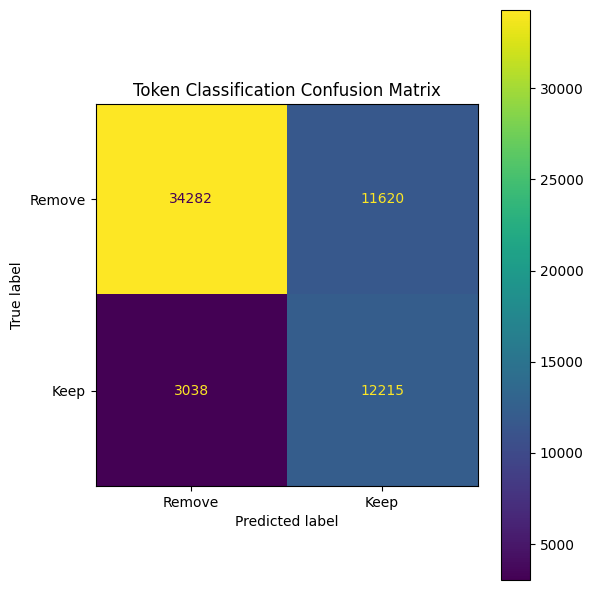

In [87]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

predictions = trainer.predict(tokenized_dataset["test"])

preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

y_true = []
y_pred = []

for pred, label in zip(preds, labels):
    for p, l in zip(pred, label):
        if l != -100:
            y_true.append(l)
            y_pred.append(p)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Remove", "Keep"]
)

disp.plot(ax=ax)

plt.title("Token Classification Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/confusion_matrix.png",
    dpi=300
)

plt.show()

In [88]:
import os

for file in [
    "/kaggle/working/training_summary.png",
    "/kaggle/working/confusion_matrix.png",
]:
    print(file, os.path.exists(file))

/kaggle/working/training_summary.png True
/kaggle/working/confusion_matrix.png True


In [89]:
import pandas as pd

history = pd.DataFrame(trainer.state.log_history)

history.to_csv(
    "/kaggle/working/training_history.csv",
    index=False
)

history.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.589967,17.663008,0.000004,0.396040,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.659010,17.821440,0.000008,0.792079,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,1.000000,51,0.989085,0.743416,0.553425,0.493239,0.521602,4.6633,43.103,2.788,NaN,NaN,NaN,NaN,NaN
3,1.427096,14.504982,0.000012,1.178218,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.355538,63.520439,0.000016,1.574257,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
